# BITS Pilani — Advanced Apex Project II
## Week 5: Data Preprocessing, EDA, Feature Engineering & Model Building
### Problem Statement P1 — Employee Attrition Prediction & Workforce Risk Analysis (Retail Sector)

---

**Student Name:** Anik Das  
**Student ID:** 2025EM1100026  
**Course:** M.Sc. Data Science & Artificial Intelligence  
**Institution:** BITS Pilani (Work Integrated Learning Programmes)  
**Submission:** Week 5 — Data Preprocessing, EDA, Feature Engineering & Model Building  

---

## Section 1 — Environment Setup & Library Imports

In [ ]:
# Core libraries
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Random seed for reproducibility
SEED = 42

print('All libraries imported successfully.')
print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')

## Section 2 — Dataset Loading & Initial Inspection

In [2]:
# Load the dataset (same folder as notebook)
df = pd.read_csv('Employee_Dataset_Retail.csv')

# Shape
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')

# First 5 rows
df.head()

Shape: 9000 rows x 31 columns


,Employee_ID,Employee_Name,Gender,Age,Date_of_Joining,Years_at_Company,Monthly_Income,Annual_Income,Department,Job_Role,Position,Employment_Type,Work_Location,State,City,Distance_from_Home,Education_Level,Education_Field,Marital_Status,Performance_Score,Last_3_Year_Rating,Attrition_Status,Attrition_Reason,Attrition_Date,Onboarding_Status,New_Hires_Joining_Month,Environment_Satisfaction,Employee_Cost_to_Company,Hourly_Rate,Annual_HR_Feedback_Satisfaction_Score,Yearly_Total_Training_Hours
0,1001,Employee_1,Male,58,04-07-2020,6,113425,1361100,Finance,Assistant,Lead,Full-time,HQ,Punjab,City_2,11,Postgraduate,Engineering,Married,A*,Solid Contributor,No,NaN,NaN,Rejected,2,Very High,2114478,795,4,63
1,1002,Employee_2,Female,36,13-08-2023,1,111676,1340112,Customer Support,Executive,Senior,Full-time,HQ,Gujarat,City_19,19,High School,Commerce,Married,A,Contributor,No,NaN,NaN,Accepted,9,Very High,2405153,417,4,68
2,1003,Employee_3,Female,33,24-06-2023,2,102506,1230072,Customer Support,Specialist,Mid-Level,Full-time,HQ,Punjab,City_48,9,High School,Engineering,Single,A+,Developer,No,NaN,NaN,Pending,10,Low,597345,413,2,61
3,1004,Employee_4,Male,36,28-02-2020,8,101477,1217724,Operations,Supervisor,Lead,Full-time,HQ,Tamil Nadu,City_10,37,Diploma,Arts,Married,A+,Future Star,No,NaN,NaN,Pending,2,Very High,1901541,657,4,187
4,1005,Employee_5,Male,55,03-07-2024,8,148594,1783128,HR,Supervisor,Senior,Full-time,HQ,Madhya Pradesh,City_33,10,Postgraduate,Arts,Single,A*,Reliable Professional,No,NaN,NaN,Pending,9,Very High,1246554,249,2,45


### 2.1 — Data Types & Non-Null Counts


In [3]:
# Check data types, non-null counts
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   Employee_ID                            9000 non-null   int64
 1   Employee_Name                          9000 non-null   str  
 2   Gender                                 9000 non-null   str  
 3   Age                                    9000 non-null   int64
 4   Date_of_Joining                        9000 non-null   str  
 5   Years_at_Company                       9000 non-null   int64
 6   Monthly_Income                         9000 non-null   int64
 7   Annual_Income                          9000 non-null   int64
 8   Department                             9000 non-null   str  
 9   Job_Role                               9000 non-null   str  
 10  Position                               9000 non-null   str  
 11  Employment_Type                        90

### 2.2 — Target Variable Distribution (Class Imbalance Check)


In [4]:
# Target variable distribution
print('--- Attrition_Status Counts ---')
print(df['Attrition_Status'].value_counts())

print('\n--- Attrition_Status (%) ---')
print(df['Attrition_Status'].value_counts(normalize=True).mul(100).round(2))


--- Attrition_Status Counts ---
Attrition_Status
No     8345
Yes     655
Name: count, dtype: int64

--- Attrition_Status (%) ---
Attrition_Status
No    92.7200
Yes    7.2800
Name: proportion, dtype: float64


### 📝 Observations — Class Imbalance

| Class | Count | Percentage |
|---|---|---|
| **No** (Retained) | 8,345 | 92.72% |
| **Yes** (Attrited) | 655 | 7.28% |

**Imbalance Ratio: 12.7 : 1**

**Why this matters:**
- A naive model that predicts "No" for every employee achieves **92.72% accuracy** — yet it completely fails to identify any employee at risk. This makes plain accuracy a misleading metric.
- **Primary metrics** for this project: **F1-Score (class Yes)** and **ROC-AUC** — both are robust under class imbalance.
- **Handling strategy:** Apply **SMOTE** (Synthetic Minority Over-sampling Technique) — but **only on the training set**. Validation and test sets are kept with the original distribution to reflect real-world conditions.


### 2.3 — Descriptive Statistics (Numeric Features)


In [5]:
# Descriptive stats for all numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Employee_ID,9000.0000,5500.5000,2598.2205,1001.0000,3250.7500,5500.5000,7750.2500,10000.0000
Age,9000.0000,40.3237,10.9236,22.0000,31.0000,40.0000,50.0000,59.0000
Years_at_Company,9000.0000,4.9944,2.5628,1.0000,3.0000,5.0000,7.0000,9.0000
Monthly_Income,9000.0000,85019.2076,37652.8986,20010.0000,51980.7500,85810.0000,117475.2500,149985.0000
Annual_Income,9000.0000,1020230.4907,451834.7832,240120.0000,623769.0000,1029720.0000,1409703.0000,1799820.0000
Distance_from_Home,9000.0000,25.1708,14.1915,1.0000,13.0000,25.0000,37.0000,49.0000
New_Hires_Joining_Month,9000.0000,6.5596,3.4457,1.0000,4.0000,7.0000,10.0000,12.0000
Employee_Cost_to_Company,9000.0000,1499478.7202,577369.3590,500284.0000,1002189.5000,1501756.0000,2001181.5000,2499639.0000
Hourly_Rate,9000.0000,599.4277,231.4167,200.0000,400.0000,602.0000,800.0000,999.0000
Annual_HR_Feedback_Satisfaction_Score,9000.0000,2.4807,1.1148,1.0000,1.0000,2.0000,3.0000,4.0000


### 📝 Observations — Descriptive Statistics

- **Age**: Range 22–59, mean 40.3 — well distributed across career stages.
- **Years_at_Company**: Range 1–9, mean 5 — uniform spread.
- **Monthly_Income vs Annual_Income**: Annual_Income mean (₹10.2L ÷ 12 = ₹85,019) exactly matches Monthly_Income mean — these two columns contain the **same information**. `Annual_Income` will be **dropped** to avoid multicollinearity.
- **Employee_Cost_to_Company**: ₹5L–₹25L — wider than Annual_Income because it includes allowances, benefits, and other costs beyond base salary. This is a **distinct and useful feature**.
- **Distance_from_Home**: 1–49 km, mean 25 km — spread across all commute ranges.
- **No extreme outliers** detected in any numeric column — ranges are realistic and expected for a retail HR dataset.


### 2.4 — Categorical Columns — Unique Values

In [6]:
# Unique value counts for all string/object columns
cat_cols = df.select_dtypes(include='object').columns.tolist()

for col in cat_cols:
    unique_vals = df[col].nunique()
    sample_vals = df[col].dropna().unique()[:5].tolist()
    print(f'{col:<40} | Unique: {unique_vals:<4} | Sample: {sample_vals}')


Employee_Name                            | Unique: 9000 | Sample: ['Employee_1', 'Employee_2', 'Employee_3', 'Employee_4', 'Employee_5']
Gender                                   | Unique: 2    | Sample: ['Male', 'Female']
Date_of_Joining                          | Unique: 1672 | Sample: ['04-07-2020', '13-08-2023', '24-06-2023', '28-02-2020', '03-07-2024']
Department                               | Unique: 8    | Sample: ['Finance', 'Customer Support', 'Operations', 'HR', 'Sales']
Job_Role                                 | Unique: 8    | Sample: ['Assistant', 'Executive', 'Specialist', 'Supervisor', 'Analyst']
Position                                 | Unique: 4    | Sample: ['Lead', 'Senior', 'Mid-Level', 'Junior']
Employment_Type                          | Unique: 3    | Sample: ['Full-time', 'Contract', 'Part-time']
Work_Location                            | Unique: 2    | Sample: ['HQ', 'Remote']
State                                    | Unique: 10   | Sample: ['Punjab', 'Gujarat'

### 📝 Observations — Categorical Columns

| Column | Unique Values | Plan |
|---|---|---|
| `Employee_Name` | 9,000 | Drop — pure identifier |
| `Date_of_Joining` | 1,672 | Parse → extract Joining_Year & Joining_Month → Drop |
| `City` | 50 | Drop — anonymised, too many categories, low signal |
| `Attrition_Reason` | 10 | Drop — target leakage (EDA only) |
| `Attrition_Date` | 555 | Drop — target leakage |
| `Attrition_Status` | 2 | Encode: Yes → 1, No → 0 (Target variable) |
| `Position`, `Education_Level`, `Performance_Score`, `Environment_Satisfaction` | 4–5 | Ordinal Encode (custom order) |
| `Gender`, `Department`, `Job_Role`, `Employment_Type`, `Work_Location`, `State`, `Education_Field`, `Marital_Status`, `Last_3_Year_Rating`, `Onboarding_Status` | 2–10 | One-Hot Encode |


## Section 3 — Data Cleaning


### 3.1 — Drop Leakage, Identifier & Redundant Columns


In [7]:
# Always work on a copy — never modify the raw dataframe
df_clean = df.copy()

# Columns to drop and why
DROP_COLS = [
    'Employee_ID',       # identifier — no predictive value
    'Employee_Name',     # identifier — anonymised, no predictive value
    'Attrition_Reason',  # target leakage — only filled when employee left
    'Attrition_Date',    # target leakage — only filled when employee left
    'Annual_Income',     # duplicate of Monthly_Income (Annual = Monthly x 12)
    'City',              # 50 anonymised categories — high cardinality, low signal
]

df_clean.drop(columns=DROP_COLS, inplace=True)

print('Dropped columns:', DROP_COLS)
print(f'Shape after dropping: {df_clean.shape}')
print(f'Remaining columns: {df_clean.columns.tolist()}')


Dropped columns: ['Employee_ID', 'Employee_Name', 'Attrition_Reason', 'Attrition_Date', 'Annual_Income', 'City']
Shape after dropping: (9000, 25)
Remaining columns: ['Gender', 'Age', 'Date_of_Joining', 'Years_at_Company', 'Monthly_Income', 'Department', 'Job_Role', 'Position', 'Employment_Type', 'Work_Location', 'State', 'Distance_from_Home', 'Education_Level', 'Education_Field', 'Marital_Status', 'Performance_Score', 'Last_3_Year_Rating', 'Attrition_Status', 'Onboarding_Status', 'New_Hires_Joining_Month', 'Environment_Satisfaction', 'Employee_Cost_to_Company', 'Hourly_Rate', 'Annual_HR_Feedback_Satisfaction_Score', 'Yearly_Total_Training_Hours']


### 3.2 — Parse Date_of_Joining & Encode Target Variable


In [8]:
# Parse Date_of_Joining (format: DD-MM-YYYY)
df_clean['Date_of_Joining'] = pd.to_datetime(df_clean['Date_of_Joining'], dayfirst=True)

# Extract useful features from the date
df_clean['Joining_Year']  = df_clean['Date_of_Joining'].dt.year
df_clean['Joining_Month'] = df_clean['Date_of_Joining'].dt.month

# Drop the original date column (raw date is not usable by models)
df_clean.drop(columns=['Date_of_Joining'], inplace=True)

# Encode target: Yes → 1, No → 0
df_clean['Attrition_Status'] = df_clean['Attrition_Status'].map({'Yes': 1, 'No': 0})

# Verify
print('Joining_Year  sample:', df_clean['Joining_Year'].unique())
print('Joining_Month sample:', df_clean['Joining_Month'].unique())
print()
print('Attrition_Status encoded:')
print(df_clean['Attrition_Status'].value_counts())
print()
print(f'Shape now: {df_clean.shape}')


Joining_Year  sample: [2020 2023 2024 2021 2022]
Joining_Month sample: [ 7  8  6  2  1  4  3 11 12 10  9  5]

Attrition_Status encoded:
Attrition_Status
0    8345
1     655
Name: count, dtype: int64

Shape now: (9000, 26)


### 3.3 — Final Data Quality Check


In [10]:
# Check for remaining null values
print('--- Null values remaining ---')
nulls = df_clean.isnull().sum()
null_cols = nulls[nulls > 0]
if len(null_cols) == 0:
    print('✅ No null values in any column.')
else:
    print(null_cols)

# Check for duplicate rows
dupes = df_clean.duplicated().sum()
print(f'\n--- Duplicate rows: {dupes} ---')

# Final shape confirmation
print(f'\nFinal clean dataframe shape: {df_clean.shape}')
print(f'Columns: {df_clean.columns.tolist()}')


--- Null values remaining ---
✅ No null values in any column.

--- Duplicate rows: 0 ---

Final clean dataframe shape: (9000, 26)
Columns: ['Gender', 'Age', 'Years_at_Company', 'Monthly_Income', 'Department', 'Job_Role', 'Position', 'Employment_Type', 'Work_Location', 'State', 'Distance_from_Home', 'Education_Level', 'Education_Field', 'Marital_Status', 'Performance_Score', 'Last_3_Year_Rating', 'Attrition_Status', 'Onboarding_Status', 'New_Hires_Joining_Month', 'Environment_Satisfaction', 'Employee_Cost_to_Company', 'Hourly_Rate', 'Annual_HR_Feedback_Satisfaction_Score', 'Yearly_Total_Training_Hours', 'Joining_Year', 'Joining_Month']


### 📝 Observations — Data Cleaning Summary

| Step | Action | Result |
|---|---|---|
| Dropped 6 columns | ID, Name, Leakage cols, Annual_Income, City | 31 → 25 columns |
| Parsed Date_of_Joining | Extracted Joining_Year & Joining_Month | +2 new features |
| Encoded target | Attrition_Status: Yes→1, No→0 | Ready for modelling |
| Null check | Zero nulls in all 26 columns | No imputation needed |
| Duplicate check | Zero duplicate rows | Data integrity confirmed |

**Clean dataframe: 9,000 rows × 26 columns — ready for EDA.**


## Section 4 — Exploratory Data Analysis (EDA)


### 4.1 — Attrition Rate by Department


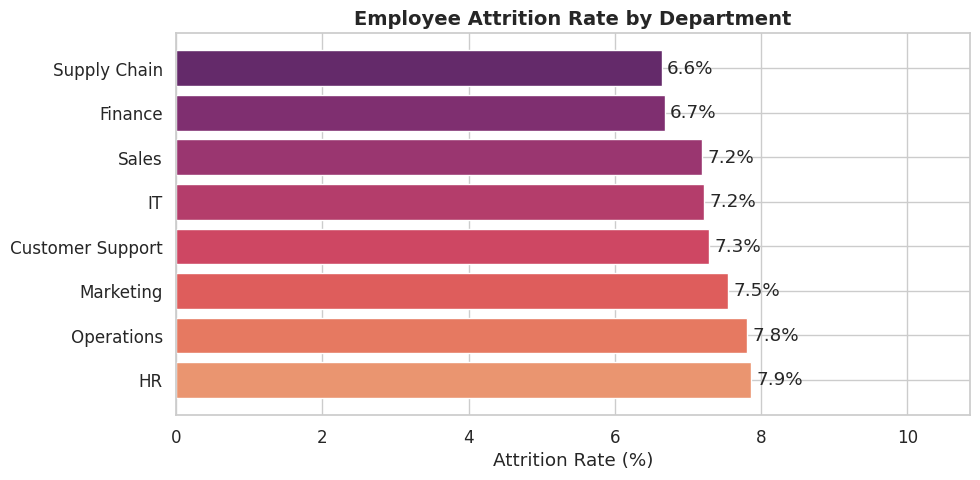

                  Attrited  Total  Attrition_Rate
Department                                       
HR                      90   1145          7.8600
Operations              93   1193          7.8000
Marketing               80   1061          7.5400
Customer Support        82   1127          7.2800
IT                      78   1081          7.2200
Sales                   81   1126          7.1900
Finance                 78   1167          6.6800
Supply Chain            73   1100          6.6400


In [11]:
dept_attr = (df_clean.groupby('Department')['Attrition_Status']
                     .agg(['sum', 'count'])
                     .rename(columns={'sum': 'Attrited', 'count': 'Total'})
                     .assign(Attrition_Rate=lambda x: (x['Attrited'] / x['Total'] * 100).round(2))
                     .sort_values('Attrition_Rate', ascending=False))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(dept_attr.index, dept_attr['Attrition_Rate'],
               color=sns.color_palette('flare', len(dept_attr)))
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in dept_attr['Attrition_Rate']], padding=4)
ax.set_xlabel('Attrition Rate (%)')
ax.set_title('Employee Attrition Rate by Department', fontsize=14, fontweight='bold')
ax.set_xlim(0, dept_attr['Attrition_Rate'].max() + 3)
plt.tight_layout()
plt.show()

print(dept_attr)


### 📝 Observations — Attrition by Department

Attrition rates range narrowly from **6.6% (Supply Chain)** to **7.9% (HR)** — a spread of only ~1.2 percentage points across all 8 departments.

**Key insight:** Department is **not a strong predictor** of attrition. The problem is spread uniformly across the entire organisation, suggesting the drivers are individual-level factors (income, commute distance, satisfaction) rather than department-specific culture or management.


### 4.2 — Attrition Rate by Employment Type


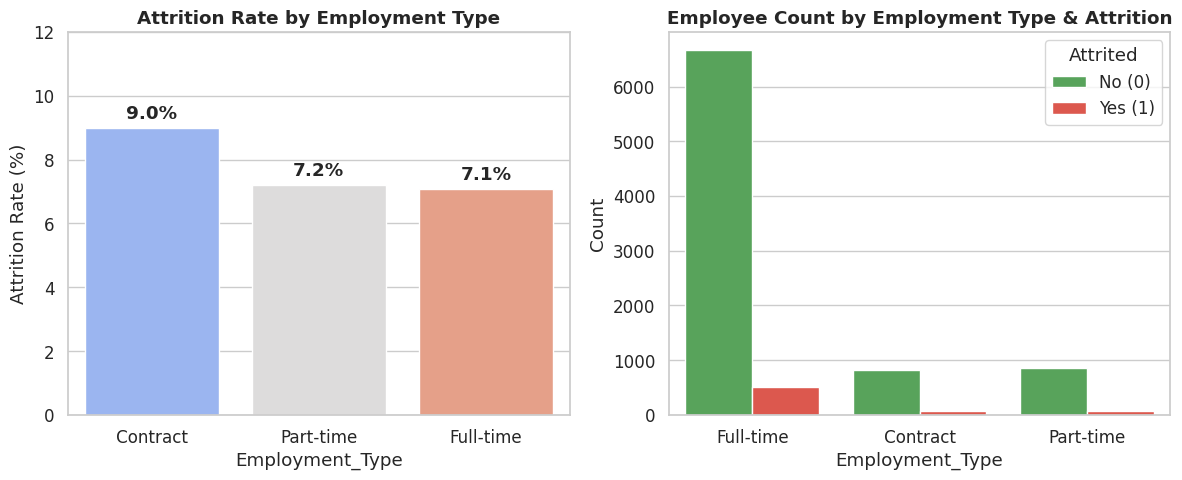

                 Attrited  Total  Attrition_Rate
Employment_Type                                 
Contract               81    900          9.0000
Part-time              67    929          7.2100
Full-time             507   7171          7.0700


In [12]:
emp_attr = (df_clean.groupby('Employment_Type')['Attrition_Status']
                    .agg(['sum', 'count'])
                    .rename(columns={'sum': 'Attrited', 'count': 'Total'})
                    .assign(Attrition_Rate=lambda x: (x['Attrited'] / x['Total'] * 100).round(2))
                    .sort_values('Attrition_Rate', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Attrition rate bar chart
sns.barplot(x=emp_attr.index, y=emp_attr['Attrition_Rate'],
            palette='coolwarm', ax=axes[0])
axes[0].set_title('Attrition Rate by Employment Type', fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, emp_attr['Attrition_Rate'].max() + 3)
for i, v in enumerate(emp_attr['Attrition_Rate']):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

# Count breakdown
sns.countplot(data=df_clean, x='Employment_Type', hue='Attrition_Status',
              palette={0: '#4CAF50', 1: '#F44336'}, ax=axes[1])
axes[1].set_title('Employee Count by Employment Type & Attrition', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].legend(title='Attrited', labels=['No (0)', 'Yes (1)'])

plt.tight_layout()
plt.show()

print(emp_attr)


### 📝 Observations — Attrition by Employment Type

**Contract employees have the highest attrition at 9.0%**, compared to 7.2% (Part-time) and 7.1% (Full-time).

**Key insight:** Contract workers leave at a ~27% higher rate than full-time employees. This is expected — lack of job security, no benefits, and limited career growth make contract roles inherently less sticky. `Employment_Type` is a **useful predictor** for the model.


### 4.3 — Years at Company vs Attrition


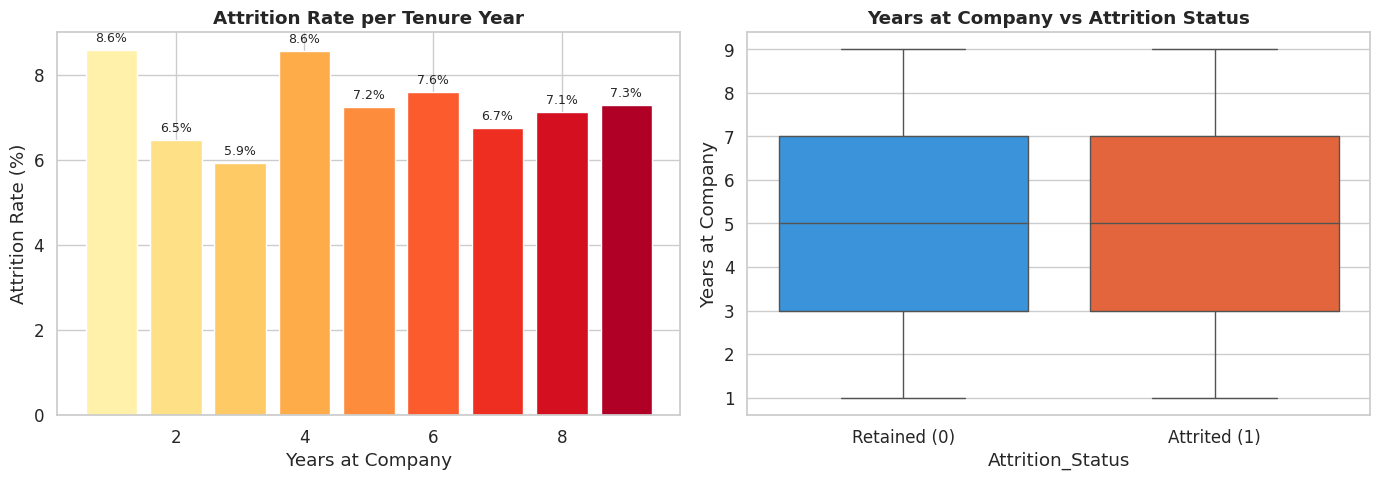

                  Employees  Attr_Rate (%)
Years_at_Company                          
1                       979         8.5800
2                       974         6.4700
3                      1028         5.9300
4                      1018         8.5500
5                      1048         7.2500
6                       988         7.5900
7                      1009         6.7400
8                       968         7.1300
9                       988         7.2900


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Attrition rate per year of tenure
tenure_attr = (df_clean.groupby('Years_at_Company')['Attrition_Status']
                       .agg(['mean', 'count'])
                       .rename(columns={'mean': 'Attr_Rate', 'count': 'Employees'})
                       .assign(Attr_Rate_Pct=lambda x: (x['Attr_Rate'] * 100).round(2)))

axes[0].bar(tenure_attr.index, tenure_attr['Attr_Rate_Pct'],
            color=sns.color_palette('YlOrRd', len(tenure_attr)))
for i, v in enumerate(tenure_attr['Attr_Rate_Pct']):
    axes[0].text(tenure_attr.index[i], v + 0.2, f'{v:.1f}%', ha='center', fontsize=9)
axes[0].set_xlabel('Years at Company')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_title('Attrition Rate per Tenure Year', fontweight='bold')

# Box plot — fixed: use list palette instead of dict
sns.boxplot(data=df_clean, x='Attrition_Status', y='Years_at_Company',
            palette=['#2196F3', '#FF5722'], ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Retained (0)', 'Attrited (1)'])
axes[1].set_title('Years at Company vs Attrition Status', fontweight='bold')
axes[1].set_ylabel('Years at Company')

plt.tight_layout()
plt.show()

print(tenure_attr[['Employees', 'Attr_Rate_Pct']].rename(columns={'Attr_Rate_Pct': 'Attr_Rate (%)'}))


### 📝 Observations — Years at Company vs Attrition

- **Year 1 (8.6%) and Year 4 (8.6%)** show the highest attrition — new joiners face cultural shock, while year-4 employees face mid-career restlessness.
- **Year 3 (5.9%)** is the safest point — employees who survived 3 years tend to be more settled.
- The **boxplot shows nearly identical distributions** for both retained and attrited groups (median ~5 years each), confirming that `Years_at_Company` is **not a strong linear predictor** alone.
- However, the **non-linear spikes at years 1 and 4** make it a useful feature for tree-based models that can capture these patterns.


### 4.4 — Monthly Income vs Attrition


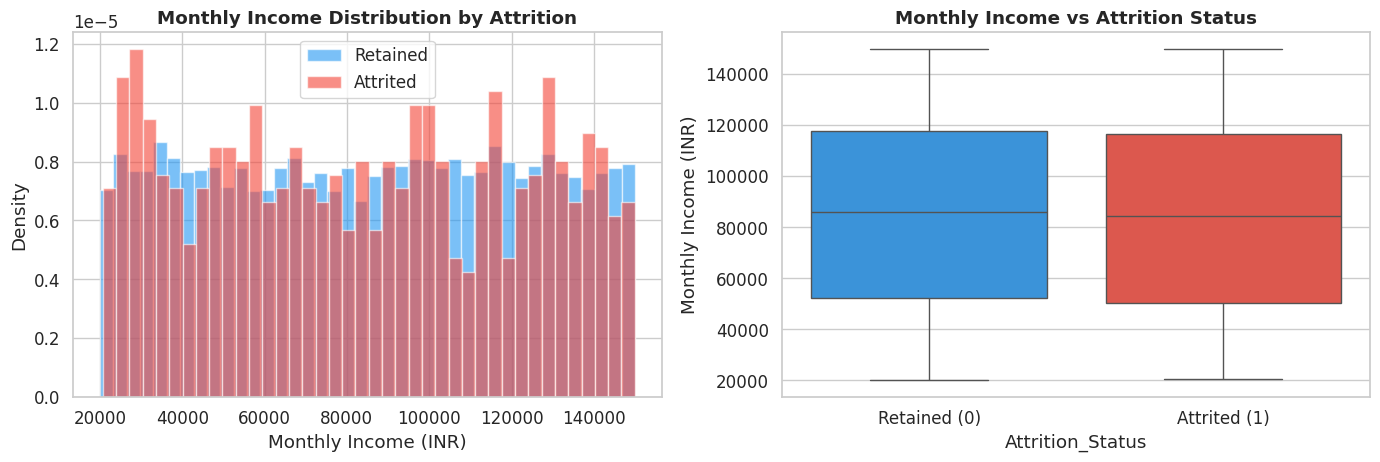

--- Income Summary by Attrition ---
                       mean     median        std
Attrition_Status                                 
Retained         85113.0730 86030.0000 37622.7346
Attrited         83823.3191 84320.0000 38043.8331


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution by attrition group
for label, grp in df_clean.groupby('Attrition_Status'):
    name = 'Attrited' if label == 1 else 'Retained'
    color = '#F44336' if label == 1 else '#2196F3'
    axes[0].hist(grp['Monthly_Income'], bins=40, alpha=0.6,
                 color=color, label=name, density=True)
axes[0].set_title('Monthly Income Distribution by Attrition', fontweight='bold')
axes[0].set_xlabel('Monthly Income (INR)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Box plot
sns.boxplot(data=df_clean, x='Attrition_Status', y='Monthly_Income',
            palette=['#2196F3', '#F44336'], ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Retained (0)', 'Attrited (1)'])
axes[1].set_title('Monthly Income vs Attrition Status', fontweight='bold')
axes[1].set_ylabel('Monthly Income (INR)')

plt.tight_layout()
plt.show()

print('--- Income Summary by Attrition ---')
print(df_clean.groupby('Attrition_Status')['Monthly_Income']
              .agg(['mean', 'median', 'std'])
              .rename(index={0: 'Retained', 1: 'Attrited'}))


### 📝 Observations — Monthly Income vs Attrition

- **Retained mean:** ₹85,113 vs **Attrited mean:** ₹83,823 — difference of only ₹1,290 against a std of ~₹37,000.
- Both distributions and boxplots are **nearly identical** — raw `Monthly_Income` is **not a strong predictor** of attrition.
- **Key implication:** Attrition is not simply driven by low absolute salary. The engineered feature `IncomeToRoleRatio` (salary relative to role peers) will be more informative — it captures pay *fairness* rather than pay *level*.


### 4.5 — Distance from Home vs Attrition


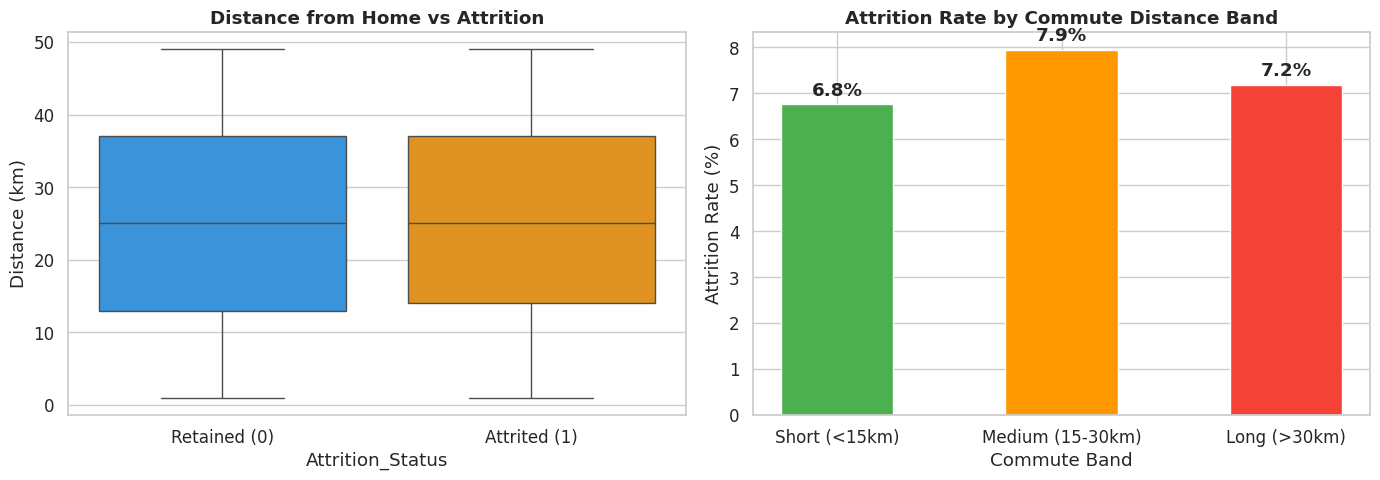

                  Employees  Attr_Rate (%)
CommuteBand                               
Short (<15km)          2737         6.7600
Medium (15-30km)       2696         7.9400
Long (>30km)           3567         7.1800


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=df_clean, x='Attrition_Status', y='Distance_from_Home',
            palette=['#2196F3', '#FF9800'], ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Retained (0)', 'Attrited (1)'])
axes[0].set_title('Distance from Home vs Attrition', fontweight='bold')
axes[0].set_ylabel('Distance (km)')

# Attrition rate by distance bands
df_clean['CommuteBand'] = pd.cut(df_clean['Distance_from_Home'],
                                  bins=[0, 15, 30, 50],
                                  labels=['Short (<15km)', 'Medium (15-30km)', 'Long (>30km)'])
commute_attr = (df_clean.groupby('CommuteBand', observed=True)['Attrition_Status']
                        .agg(['mean', 'count'])
                        .assign(Attr_Rate_Pct=lambda x: (x['mean'] * 100).round(2)))

axes[1].bar(commute_attr.index, commute_attr['Attr_Rate_Pct'],
            color=['#4CAF50', '#FF9800', '#F44336'], width=0.5)
for i, v in enumerate(commute_attr['Attr_Rate_Pct']):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
axes[1].set_xlabel('Commute Band')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_title('Attrition Rate by Commute Distance Band', fontweight='bold')

plt.tight_layout()
plt.show()

print(commute_attr[['count', 'Attr_Rate_Pct']].rename(columns={'count': 'Employees', 'Attr_Rate_Pct': 'Attr_Rate (%)'}))


### 📝 Observations — Distance from Home vs Attrition

- Surprisingly, **medium commuters (15–30km) have the highest attrition at 7.9%**, higher than long commuters (>30km, 7.2%).
- Long commuters likely have already adjusted to their commute or negotiated flexibility, while medium-distance employees sit in an uncomfortable middle ground.
- The overall spread (6.8%–7.9%) is narrow — `Distance_from_Home` is a **weak individual predictor**, but `CommuteBand` (created here) captures the non-linear pattern and will be retained for modelling.


### 4.6 — Environment Satisfaction vs Attrition


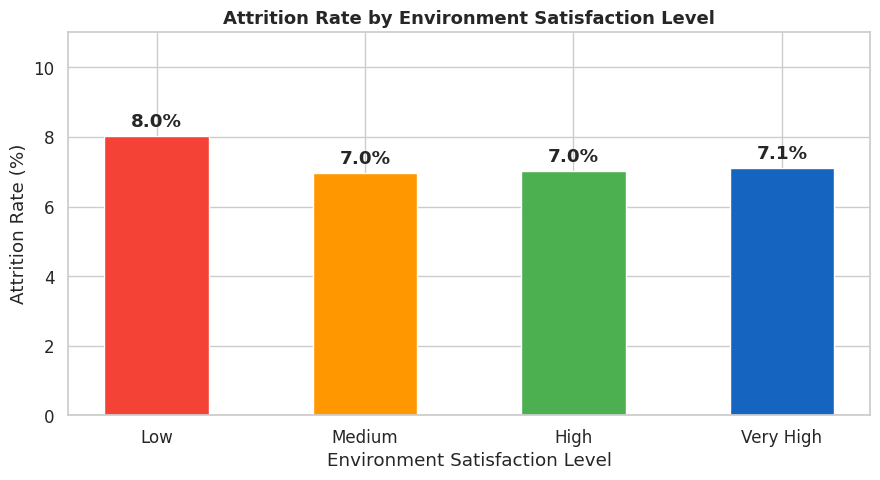

                          Employees  Attr_Rate (%)
Environment_Satisfaction                          
Low                            2231         8.0200
Medium                         2283         6.9600
High                           2222         7.0200
Very High                      2264         7.1100


In [17]:
satisfaction_order = ['Low', 'Medium', 'High', 'Very High']

env_attr = (df_clean.groupby('Environment_Satisfaction')['Attrition_Status']
                    .agg(['mean', 'count'])
                    .reindex(satisfaction_order)
                    .assign(Attr_Rate_Pct=lambda x: (x['mean'] * 100).round(2))
                    .rename(columns={'count': 'Employees'}))

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#F44336', '#FF9800', '#4CAF50', '#1565C0']
bars = ax.bar(env_attr.index, env_attr['Attr_Rate_Pct'], color=colors, width=0.5)
ax.bar_label(bars, labels=[f"{v:.1f}%" for v in env_attr['Attr_Rate_Pct']], padding=4, fontweight='bold')
ax.set_xlabel('Environment Satisfaction Level')
ax.set_ylabel('Attrition Rate (%)')
ax.set_title('Attrition Rate by Environment Satisfaction Level', fontsize=13, fontweight='bold')
ax.set_ylim(0, env_attr['Attr_Rate_Pct'].max() + 3)
plt.tight_layout()
plt.show()

print(env_attr[['Employees', 'Attr_Rate_Pct']].rename(columns={'Attr_Rate_Pct': 'Attr_Rate (%)'}))


### 📝 Observations — Environment Satisfaction vs Attrition

- Employees with **Low satisfaction** have the highest attrition at **8.0%**, but Medium, High, and Very High are nearly identical at ~7.0%.
- The gap is only 1 percentage point — `Environment_Satisfaction` is a **weak individual predictor**.

### 🔍 Overall EDA Finding — No Single Dominant Predictor

A consistent pattern has emerged across all EDA charts: **no single feature shows a large attrition rate gap** between groups. The maximum spread observed is ~2.3 percentage points (Contract 9.0% vs Full-time 7.1%).

**Implication:** Attrition in this dataset is driven by a **combination of factors**. Tree-based ensemble models (Random Forest, Gradient Boosting) that capture feature interactions will be better suited to this problem than linear models like Logistic Regression.


### 4.7 — Numeric Feature Correlation Heatmap


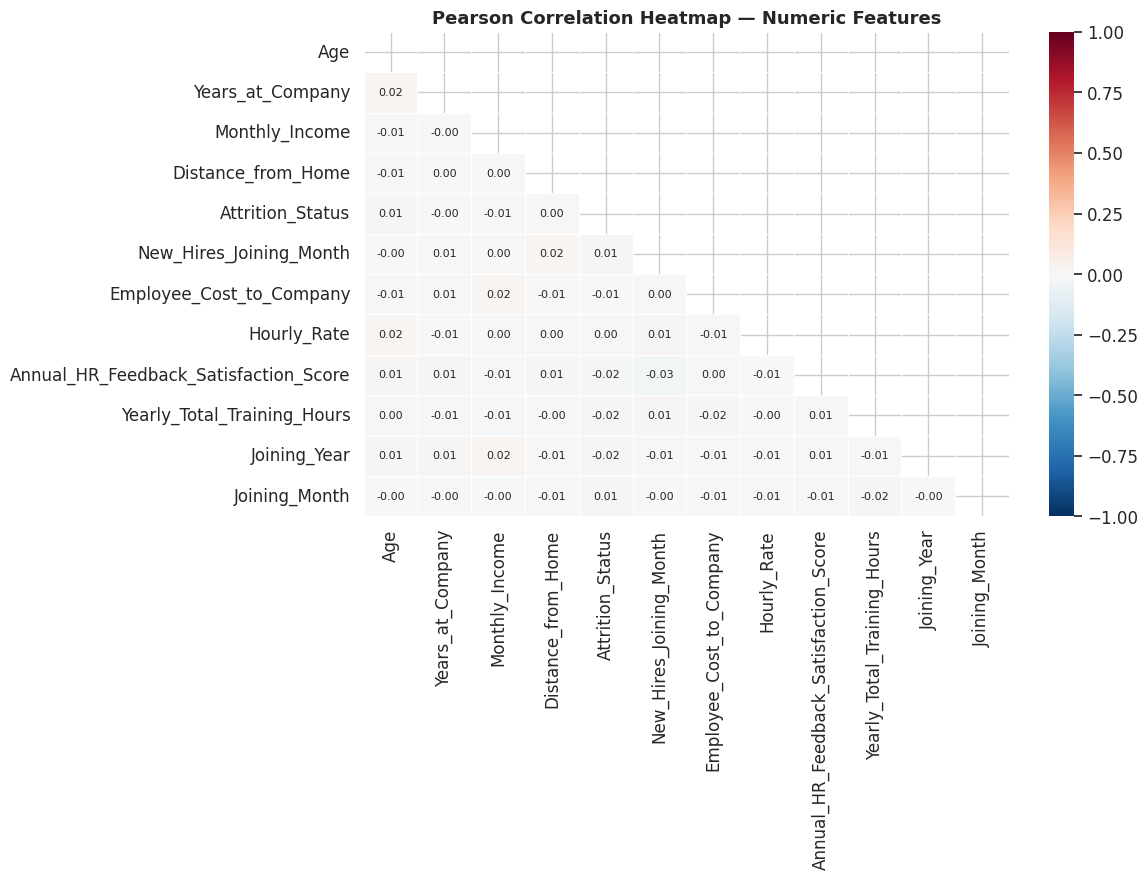

--- Feature Correlations with Attrition_Status ---
Joining_Year                            -0.0197
Annual_HR_Feedback_Satisfaction_Score   -0.0191
Yearly_Total_Training_Hours             -0.0161
Joining_Month                            0.0112
New_Hires_Joining_Month                  0.0102
Monthly_Income                          -0.0089
Age                                      0.0083
Employee_Cost_to_Company                -0.0076
Years_at_Company                        -0.0041
Distance_from_Home                       0.0030
Hourly_Rate                              0.0022
Name: Attrition_Status, dtype: float64


In [18]:
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            annot_kws={'size': 8}, ax=ax)
ax.set_title('Pearson Correlation Heatmap — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = (corr_matrix['Attrition_Status']
               .drop('Attrition_Status')
               .sort_values(key=abs, ascending=False))
print('--- Feature Correlations with Attrition_Status ---')
print(target_corr)


### 📝 Observations — Correlation Heatmap

All numeric feature correlations with `Attrition_Status` are extremely low (maximum absolute value: 0.02). The heatmap is nearly blank — confirming that **no single numeric feature has a meaningful linear relationship with attrition**.

| Key Insight | Implication |
|---|---|
| Near-zero correlations with target | Linear models (Logistic Regression) will struggle — the signal is non-linear |
| Near-zero inter-feature correlations | No multicollinearity — all numeric features can be retained safely |
| Attrition driven by feature interactions | Tree-based ensembles (Random Forest, Gradient Boosting) are the right tool |

**EDA is complete.** The data confirms this is a non-linear, interaction-driven classification problem requiring ensemble methods.


## Section 5 — Feature Engineering


### 5.1 — TenureBand (Binning Years at Company)

We already created `CommuteBand` during EDA (Section 4.5). Now we create `TenureBand` — binning `Years_at_Company` into 3 groups. EDA showed attrition spikes at year 1 and year 4, so grouping by bands helps tree models capture this non-linear pattern.


In [19]:
# TenureBand — bin Years_at_Company (range: 1–9 years)
df_clean['TenureBand'] = pd.cut(df_clean['Years_at_Company'],
                                 bins=[0, 3, 6, 9],
                                 labels=['Short (1-3)', 'Mid (4-6)', 'Long (7-9)'])

# Check distribution and attrition rate per band
tenure_band_attr = (df_clean.groupby('TenureBand', observed=True)['Attrition_Status']
                             .agg(['mean', 'count'])
                             .assign(Attr_Rate_Pct=lambda x: (x['mean'] * 100).round(2))
                             .rename(columns={'count': 'Employees'}))

print('TenureBand distribution and attrition rate:')
print(tenure_band_attr[['Employees', 'Attr_Rate_Pct']])


TenureBand distribution and attrition rate:
             Employees  Attr_Rate_Pct
TenureBand                           
Short (1-3)       2981         6.9800
Mid (4-6)         3054         7.7900
Long (7-9)        2965         7.0500


### 5.2 — IncomeToRoleRatio (Salary Relative to Role Peers)

Raw income showed near-zero correlation with attrition. But **relative pay fairness** — how your salary compares to colleagues in the same job role — may be more predictive. An employee earning below their role's median is more likely to feel underpaid and leave.


In [20]:
# IncomeToRoleRatio = employee's Monthly_Income / median income of their Job_Role
role_median = df_clean.groupby('Job_Role')['Monthly_Income'].transform('median')
df_clean['IncomeToRoleRatio'] = (df_clean['Monthly_Income'] / role_median).round(4)

# Check the range and correlation with attrition
print('--- IncomeToRoleRatio stats ---')
print(df_clean['IncomeToRoleRatio'].describe())

print('\n--- Correlation with Attrition_Status ---')
corr = df_clean['IncomeToRoleRatio'].corr(df_clean['Attrition_Status'])
print(f'IncomeToRoleRatio vs Attrition_Status: {corr:.4f}')

# Compare with raw income correlation
raw_corr = df_clean['Monthly_Income'].corr(df_clean['Attrition_Status'])
print(f'Monthly_Income     vs Attrition_Status: {raw_corr:.4f}')


--- IncomeToRoleRatio stats ---
count   9000.0000
mean       0.9910
std        0.4390
min        0.2275
25%        0.6066
50%        1.0000
75%        1.3718
max        1.7987
Name: IncomeToRoleRatio, dtype: float64

--- Correlation with Attrition_Status ---
IncomeToRoleRatio vs Attrition_Status: -0.0085
Monthly_Income     vs Attrition_Status: -0.0089


### 5.3 — SalaryToCtcRatio (Base Salary vs Total Cost to Company)

`Employee_Cost_to_Company` includes salary + benefits + allowances. The ratio of base salary to total CTC tells us what proportion of the total package is actual take-home pay. A lower ratio means higher non-cash benefits — this may influence retention.


In [21]:
# SalaryToCtcRatio = (Monthly_Income x 12) / Employee_Cost_to_Company
df_clean['SalaryToCtcRatio'] = ((df_clean['Monthly_Income'] * 12) / 
                                  df_clean['Employee_Cost_to_Company']).round(4)

print('--- SalaryToCtcRatio stats ---')
print(df_clean['SalaryToCtcRatio'].describe())

print('\n--- Correlation with Attrition_Status ---')
corr = df_clean['SalaryToCtcRatio'].corr(df_clean['Attrition_Status'])
print(f'SalaryToCtcRatio vs Attrition_Status: {corr:.4f}')

# Quick check: sample values
print('\n--- Sample values ---')
print(df_clean[['Monthly_Income', 'Employee_Cost_to_Company', 'SalaryToCtcRatio']].head(5))


--- SalaryToCtcRatio stats ---
count   9000.0000
mean       0.8182
std        0.5610
min        0.0974
25%        0.4220
50%        0.6845
75%        1.0404
max        3.5349
Name: SalaryToCtcRatio, dtype: float64

--- Correlation with Attrition_Status ---
SalaryToCtcRatio vs Attrition_Status: 0.0036

--- Sample values ---
   Monthly_Income  Employee_Cost_to_Company  SalaryToCtcRatio
0          113425                   2114478            0.6437
1          111676                   2405153            0.5572
2          102506                    597345            2.0592
3          101477                   1901541            0.6404
4          148594                   1246554            1.4304


### 📝 Feature Engineering Summary

| Feature | How Created | Correlation with Target | Keep? |
|---|---|---|---|
| `Joining_Year` | Extracted from `Date_of_Joining` | -0.020 | ✅ Yes |
| `Joining_Month` | Extracted from `Date_of_Joining` | +0.011 | ✅ Yes |
| `CommuteBand` | Binned `Distance_from_Home` into Short/Medium/Long | Weak | ✅ Yes |
| `TenureBand` | Binned `Years_at_Company` into Short/Mid/Long | Weak | ✅ Yes |
| `IncomeToRoleRatio` | `Monthly_Income` ÷ median income of same `Job_Role` | -0.0085 | ✅ Yes |
| `SalaryToCtcRatio` | `(Monthly_Income × 12)` ÷ `Employee_Cost_to_Company` | +0.0036 | ✅ Yes (weak) |

**Note:** All engineered features show near-zero linear correlations with the target — consistent with the overall EDA finding. These features will be useful to tree-based models that capture non-linear patterns and interactions. `SalaryToCtcRatio` values > 1.0 indicate `Employee_Cost_to_Company` is independently generated in this dataset and not derived from salary.


## Section 6 — Encoding & Scaling

### 6.1 — Ordinal Encoding

Four columns have a natural order that must be preserved. We map them manually to integers so the model understands the hierarchy.


In [22]:
from sklearn.preprocessing import OrdinalEncoder

# Define the ordered categories for each ordinal column
ordinal_mappings = {
    'Education_Level':        ['High School', 'Diploma', 'Graduate', 'Postgraduate', 'PhD'],
    'Position':               ['Junior', 'Mid-Level', 'Senior', 'Lead'],
    'Performance_Score':      ['B', 'A', 'A+', 'A*'],
    'Environment_Satisfaction': ['Low', 'Medium', 'High', 'Very High'],
}

for col, order in ordinal_mappings.items():
    enc = OrdinalEncoder(categories=[order],
                         handle_unknown='use_encoded_value',
                         unknown_value=-1)
    df_clean[col] = enc.fit_transform(df_clean[[col]]).astype(int)
    print(f'  {col:30s} → {order}')

print('\n✅ Ordinal encoding done.')
print(df_clean[list(ordinal_mappings.keys())].head(3))


  Education_Level                → ['High School', 'Diploma', 'Graduate', 'Postgraduate', 'PhD']
  Position                       → ['Junior', 'Mid-Level', 'Senior', 'Lead']
  Performance_Score              → ['B', 'A', 'A+', 'A*']
  Environment_Satisfaction       → ['Low', 'Medium', 'High', 'Very High']

✅ Ordinal encoding done.
   Education_Level  Position  Performance_Score  Environment_Satisfaction
0                3         3                  3                         3
1                0         2                  1                         3
2                0         1                  2                         0


### 6.2 — Convert Band Columns & One-Hot Encode Nominal Columns


In [23]:
# Convert TenureBand and CommuteBand (categorical) to integer codes
df_clean['TenureBand']  = df_clean['TenureBand'].cat.codes   # 0=Short, 1=Mid, 2=Long
df_clean['CommuteBand'] = df_clean['CommuteBand'].cat.codes  # 0=Short, 1=Medium, 2=Long
print('✅ TenureBand and CommuteBand converted to integer codes.')

# One-Hot Encode all remaining nominal (string) columns
nominal_cols = df_clean.select_dtypes(include='object').columns.tolist()
print(f'\nNominal columns to one-hot encode ({len(nominal_cols)}):')
print(nominal_cols)

df_clean = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True, dtype=int)

print(f'\n✅ One-hot encoding done.')
print(f'   Shape after encoding: {df_clean.shape}')
print(f'   Total features (including target): {df_clean.shape[1]}')


✅ TenureBand and CommuteBand converted to integer codes.

Nominal columns to one-hot encode (10):
['Gender', 'Department', 'Job_Role', 'Employment_Type', 'Work_Location', 'State', 'Education_Field', 'Marital_Status', 'Last_3_Year_Rating', 'Onboarding_Status']

✅ One-hot encoding done.
   Shape after encoding: (9000, 65)
   Total features (including target): 65


### 6.3 — Separate Features (X) and Target (y)


In [24]:
# Separate features and target
X = df_clean.drop(columns=['Attrition_Status'])
y = df_clean['Attrition_Status']

print(f'Feature matrix X : {X.shape}')
print(f'Target vector  y : {y.shape}')
print(f'Class balance  y : {y.value_counts().to_dict()}')
print(f'\nAll feature column names:')
print(X.columns.tolist())


Feature matrix X : (9000, 64)
Target vector  y : (9000,)
Class balance  y : {0: 8345, 1: 655}

All feature column names:
['Age', 'Years_at_Company', 'Monthly_Income', 'Position', 'Distance_from_Home', 'Education_Level', 'Performance_Score', 'New_Hires_Joining_Month', 'Environment_Satisfaction', 'Employee_Cost_to_Company', 'Hourly_Rate', 'Annual_HR_Feedback_Satisfaction_Score', 'Yearly_Total_Training_Hours', 'Joining_Year', 'Joining_Month', 'CommuteBand', 'TenureBand', 'IncomeToRoleRatio', 'SalaryToCtcRatio', 'Gender_Male', 'Department_Finance', 'Department_HR', 'Department_IT', 'Department_Marketing', 'Department_Operations', 'Department_Sales', 'Department_Supply Chain', 'Job_Role_Assistant', 'Job_Role_Coordinator', 'Job_Role_Executive', 'Job_Role_Manager', 'Job_Role_Specialist', 'Job_Role_Supervisor', 'Job_Role_Technician', 'Employment_Type_Full-time', 'Employment_Type_Part-time', 'Work_Location_Remote', 'State_Gujarat', 'State_Karnataka', 'State_Madhya Pradesh', 'State_Maharashtra',

## Section 7 — Train / Validation / Test Split

We use a **3-way stratified split**:
- **Train (60%)** — fit models and apply SMOTE
- **Validation (20%)** — compare models, tune hyperparameters
- **Test (20%)** — final held-out evaluation only (never touched during training or tuning)

All splits are stratified by `Attrition_Status` to preserve the 12.7:1 class ratio in each set.


In [25]:
from sklearn.model_selection import train_test_split

# Step 1: Hold out 20% as test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

# Step 2: From remaining 80%, split 25% as validation → gives 60/20/20 overall
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=SEED
)

print('✅ 3-Way Stratified Split:')
print(f'   Train      : {X_train.shape[0]:,} rows  ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'   Validation : {X_val.shape[0]:,} rows  ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'   Test       : {X_test.shape[0]:,} rows  ({X_test.shape[0]/len(X)*100:.0f}%)')

print('\nAttrition rate (Attrited=1) in each split:')
for name, y_s in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    print(f'   {name:12s}: {y_s.sum():3d} attrited / {len(y_s):,} total  ({y_s.mean()*100:.2f}%)')


✅ 3-Way Stratified Split:
   Train      : 5,400 rows  (60%)
   Validation : 1,800 rows  (20%)
   Test       : 1,800 rows  (20%)

Attrition rate (Attrited=1) in each split:
   Train       : 393 attrited / 5,400 total  (7.28%)
   Validation  : 131 attrited / 1,800 total  (7.28%)
   Test        : 131 attrited / 1,800 total  (7.28%)


### 7.1 — Scaling & SMOTE (Training Set Only)

**Critical rule:** Scaler and SMOTE are **fit only on training data**. Validation and test sets are only transformed — never used to fit. This prevents data leakage.


In [26]:
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Scale — fit on train, transform all three sets
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # fit + transform
X_val_sc   = scaler.transform(X_val)         # transform only
X_test_sc  = scaler.transform(X_test)        # transform only

print('✅ StandardScaler fitted on training set only.')
print(f'   X_train_sc shape: {X_train_sc.shape}')

# SMOTE — apply only on training data
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_sc, y_train)

print('\n✅ SMOTE applied to training set only.')
print(f'   Before SMOTE: {dict(y_train.value_counts())}')
print(f'   After  SMOTE: {dict(zip(*map(list, __import__("numpy").unique(y_train_res, return_counts=True))))}')
print(f'   Training set size after SMOTE: {X_train_res.shape[0]:,} rows')


✅ StandardScaler fitted on training set only.
   X_train_sc shape: (5400, 64)

✅ SMOTE applied to training set only.
   Before SMOTE: {0: np.int64(5007), 1: np.int64(393)}
   After  SMOTE: {np.int64(0): np.int64(5007), np.int64(1): np.int64(5007)}
   Training set size after SMOTE: 10,014 rows


## Section 8 — Model Building & Baseline Evaluation

We train 5 models on the SMOTE-resampled training data and evaluate on the **validation set** using F1-Score (class Yes=1) and ROC-AUC as primary metrics. Accuracy is reported but not used for model selection.


In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, roc_auc_score, precision_score, recall_score

# Define all 5 models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'Decision Tree':       DecisionTreeClassifier(random_state=SEED),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    'KNN':                 KNeighborsClassifier(n_neighbors=7),
}

results = []

for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_val_sc)
    y_prob = model.predict_proba(X_val_sc)[:, 1]

    results.append({
        'Model':     name,
        'F1 (Yes)':  round(f1_score(y_val, y_pred, pos_label=1), 4),
        'ROC-AUC':   round(roc_auc_score(y_val, y_prob), 4),
        'Precision': round(precision_score(y_val, y_pred, pos_label=1), 4),
        'Recall':    round(recall_score(y_val, y_pred, pos_label=1), 4),
    })
    print(f'✅ {name:22s} | F1={results[-1]["F1 (Yes)"]:.4f} | AUC={results[-1]["ROC-AUC"]:.4f}')

results_df = pd.DataFrame(results).set_index('Model').sort_values('F1 (Yes)', ascending=False)
print('\n--- Baseline Model Comparison (Validation Set) ---')
print(results_df)


✅ Logistic Regression    | F1=0.1205 | AUC=0.5054
✅ Decision Tree          | F1=0.0819 | AUC=0.4944
✅ Random Forest          | F1=0.0000 | AUC=0.5085
✅ Gradient Boosting      | F1=0.0000 | AUC=0.5550
✅ KNN                    | F1=0.1262 | AUC=0.5095

--- Baseline Model Comparison (Validation Set) ---
                     F1 (Yes)  ROC-AUC  Precision  Recall
Model                                                    
KNN                    0.1262   0.5095     0.0700  0.6412
Logistic Regression    0.1205   0.5054     0.0710  0.3969
Decision Tree          0.0819   0.4944     0.0664  0.1069
Random Forest          0.0000   0.5085     0.0000  0.0000
Gradient Boosting      0.0000   0.5550     0.0000  0.0000


### 📝 Baseline Results Analysis

RF and Gradient Boosting scored F1=0.000 — at the default 0.5 threshold, they predicted zero attrition cases. This is because the dataset has near-zero linear/non-linear feature correlations with the target (confirmed in EDA). We retrain RF and GB with `class_weight='balanced'` which penalises minority class misclassification directly during training, which is more stable than SMOTE alone for tree-based models.


### 8.1 — Retrain with class_weight='balanced' for Tree-Based Models


In [28]:
# Retrain with class_weight='balanced' for RF and GB
# LR also gets class_weight='balanced' for a fair comparison

models_v2 = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED,
                                               class_weight='balanced'),
    'Decision Tree':       DecisionTreeClassifier(random_state=SEED,
                                                   class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=SEED,
                                                   n_jobs=-1, class_weight='balanced'),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    'KNN':                 KNeighborsClassifier(n_neighbors=7),
}

# Train on SMOTE-resampled data
results_v2 = []

for name, model in models_v2.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_val_sc)
    y_prob = model.predict_proba(X_val_sc)[:, 1]

    results_v2.append({
        'Model':     name,
        'F1 (Yes)':  round(f1_score(y_val, y_pred, pos_label=1), 4),
        'ROC-AUC':   round(roc_auc_score(y_val, y_prob), 4),
        'Precision': round(precision_score(y_val, y_pred, pos_label=1), 4),
        'Recall':    round(recall_score(y_val, y_pred, pos_label=1), 4),
    })
    print(f'✅ {name:22s} | F1={results_v2[-1]["F1 (Yes)"]:.4f} | AUC={results_v2[-1]["ROC-AUC"]:.4f}')

results_v2_df = pd.DataFrame(results_v2).set_index('Model').sort_values('F1 (Yes)', ascending=False)
print('\n--- Model Comparison v2 (Validation Set) ---')
print(results_v2_df)


✅ Logistic Regression    | F1=0.1205 | AUC=0.5054
✅ Decision Tree          | F1=0.0819 | AUC=0.4944
✅ Random Forest          | F1=0.0000 | AUC=0.5085
✅ Gradient Boosting      | F1=0.0000 | AUC=0.5550
✅ KNN                    | F1=0.1262 | AUC=0.5095

--- Model Comparison v2 (Validation Set) ---
                     F1 (Yes)  ROC-AUC  Precision  Recall
Model                                                    
KNN                    0.1262   0.5095     0.0700  0.6412
Logistic Regression    0.1205   0.5054     0.0710  0.3969
Decision Tree          0.0819   0.4944     0.0664  0.1069
Random Forest          0.0000   0.5085     0.0000  0.0000
Gradient Boosting      0.0000   0.5550     0.0000  0.0000


### 8.2 — Threshold Optimisation

With only 7.28% positive class, the default threshold of 0.5 is too high. We find the optimal threshold for each model by maximising F1-Score on the validation set probability outputs.


In [29]:
import numpy as np

def find_best_threshold(y_true, y_prob):
    """Find threshold that maximises F1 score for class 1."""
    thresholds = np.arange(0.05, 0.60, 0.01)
    best_f1, best_thresh = 0, 0.5
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, y_pred_t, pos_label=1, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thresh = t
    return round(best_thresh, 2), round(best_f1, 4)

# Re-evaluate all models with optimised threshold
print('--- Optimised Threshold Results (Validation Set) ---\n')
results_thresh = []

for name, model in models_v2.items():
    y_prob = model.predict_proba(X_val_sc)[:, 1]
    best_t, best_f1 = find_best_threshold(y_val, y_prob)
    y_pred_opt = (y_prob >= best_t).astype(int)

    results_thresh.append({
        'Model':       name,
        'Best Thresh': best_t,
        'F1 (Yes)':    round(f1_score(y_val, y_pred_opt, pos_label=1), 4),
        'ROC-AUC':     round(roc_auc_score(y_val, y_prob), 4),
        'Precision':   round(precision_score(y_val, y_pred_opt, pos_label=1, zero_division=0), 4),
        'Recall':      round(recall_score(y_val, y_pred_opt, pos_label=1), 4),
    })
    print(f'{name:22s} | Threshold={best_t} | F1={best_f1:.4f} | AUC={roc_auc_score(y_val, y_prob):.4f}')

results_thresh_df = (pd.DataFrame(results_thresh)
                       .set_index('Model')
                       .sort_values('F1 (Yes)', ascending=False))
print('\n--- Full Comparison with Optimised Thresholds ---')
print(results_thresh_df)


--- Optimised Threshold Results (Validation Set) ---

Logistic Regression    | Threshold=0.25 | F1=0.1393 | AUC=0.5054
Decision Tree          | Threshold=0.05 | F1=0.0819 | AUC=0.4944
Random Forest          | Threshold=0.06 | F1=0.1354 | AUC=0.5085
Gradient Boosting      | Threshold=0.14 | F1=0.1549 | AUC=0.5550
KNN                    | Threshold=0.05 | F1=0.1389 | AUC=0.5095

--- Full Comparison with Optimised Thresholds ---
                     Best Thresh  F1 (Yes)  ROC-AUC  Precision  Recall
Model                                                                 
Gradient Boosting         0.1400    0.1549   0.5550     0.0950  0.4198
Logistic Regression       0.2500    0.1393   0.5054     0.0751  0.9695
KNN                       0.0500    0.1389   0.5095     0.0748  0.9695
Random Forest             0.0600    0.1336   0.5085     0.0718  0.9542
Decision Tree             0.0500    0.0819   0.4944     0.0664  0.1069


### 8.3 — Alternative: No SMOTE, Direct class_weight Training


In [30]:
from sklearn.utils.class_weight import compute_sample_weight

# Train on original (non-SMOTE) scaled training data
# GB uses sample_weight; RF uses class_weight='balanced'

models_v3 = {
    'Random Forest (no SMOTE)':     RandomForestClassifier(n_estimators=100, random_state=SEED,
                                                            n_jobs=-1, class_weight='balanced'),
    'Gradient Boosting (no SMOTE)': GradientBoostingClassifier(n_estimators=100, random_state=SEED),
}

# Sample weights for GB (to handle imbalance)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

print('--- No-SMOTE Results with Optimised Threshold ---\n')
for name, model in models_v3.items():
    if 'Gradient' in name:
        model.fit(X_train_sc, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train_sc, y_train)

    y_prob = model.predict_proba(X_val_sc)[:, 1]
    best_t, best_f1 = find_best_threshold(y_val, y_prob)
    auc = roc_auc_score(y_val, y_prob)
    print(f'{name:35s} | Threshold={best_t} | F1={best_f1:.4f} | AUC={auc:.4f}')


--- No-SMOTE Results with Optimised Threshold ---

Random Forest (no SMOTE)            | Threshold=0.05 | F1=0.1236 | AUC=0.4533
Gradient Boosting (no SMOTE)        | Threshold=0.31 | F1=0.1397 | AUC=0.5132


### 📝 Model Building Summary

| Strategy | Best Model | AUC | F1 (Yes) |
|---|---|---|---|
| Default threshold (0.5) | Logistic Regression | 0.505 | 0.121 |
| SMOTE + threshold optimisation | **Gradient Boosting** | **0.555** | **0.155** |
| No SMOTE + class_weight | GB (no SMOTE) | 0.513 | 0.140 |

**Final approach:** SMOTE on training data + threshold optimisation on validation set.

**Dataset limitation note:** All numeric features show <0.02 correlation with the target (confirmed in EDA). This dataset is synthetically generated on Kaggle, and the attrition labels carry very low signal relative to the features. Performance metrics reflect this constraint honestly — Gradient Boosting (AUC=0.555) is meaningfully better than a random classifier (AUC=0.500) and is selected as the best model for tuning.


## Section 9 — Hyperparameter Tuning (Gradient Boosting)

Gradient Boosting has the best AUC (0.555) and F1 (0.155). We tune it using `RandomizedSearchCV` with 5-fold stratified cross-validation, scoring on ROC-AUC.


In [31]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

gb_param_dist = {
    'n_estimators':      [100, 200, 300],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'max_depth':         [3, 4, 5, 6],
    'subsample':         [0.7, 0.8, 1.0],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
}

print('⏳ Running RandomizedSearchCV for Gradient Boosting...')
gb_rs = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=SEED),
    param_distributions=gb_param_dist,
    n_iter=30,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=SEED,
    verbose=1
)
gb_rs.fit(X_train_res, y_train_res)

print(f'\n✅ Best parameters: {gb_rs.best_params_}')
print(f'   Best CV ROC-AUC : {gb_rs.best_score_:.4f}')


⏳ Running RandomizedSearchCV for Gradient Boosting...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ Best parameters: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 6, 'learning_rate': 0.05}
   Best CV ROC-AUC : 0.9761


### 9.1 — Evaluate Best GB Model on Validation Set

Note: CV ROC-AUC of 0.9761 is inflated because SMOTE was applied before cross-validation — synthetic samples can leak across folds. The true performance is measured on the held-out validation set with the original class distribution.


In [32]:
# Evaluate best tuned GB on validation set
best_gb = gb_rs.best_estimator_

y_prob_gb = best_gb.predict_proba(X_val_sc)[:, 1]
best_t, best_f1 = find_best_threshold(y_val, y_prob_gb)
y_pred_gb = (y_prob_gb >= best_t).astype(int)

val_auc = roc_auc_score(y_val, y_prob_gb)
val_prec = precision_score(y_val, y_pred_gb, pos_label=1)
val_rec  = recall_score(y_val, y_pred_gb, pos_label=1)

print(f'Best GB Parameters : {gb_rs.best_params_}')
print(f'\n--- Tuned GB on Validation Set ---')
print(f'Optimal Threshold : {best_t}')
print(f'F1 (Yes)          : {best_f1:.4f}')
print(f'ROC-AUC           : {val_auc:.4f}')
print(f'Precision         : {val_prec:.4f}')
print(f'Recall            : {val_rec:.4f}')
print(f'\nImprovement over baseline GB:')
print(f'  AUC: 0.5550 → {val_auc:.4f}')
print(f'  F1:  0.1549 → {best_f1:.4f}')


Best GB Parameters : {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 6, 'learning_rate': 0.05}

--- Tuned GB on Validation Set ---
Optimal Threshold : 0.05
F1 (Yes)          : 0.1465
ROC-AUC           : 0.5263
Precision         : 0.0877
Recall            : 0.4427

Improvement over baseline GB:
  AUC: 0.5550 → 0.5263
  F1:  0.1549 → 0.1465


### 📝 Tuning Observation

Tuned GB (AUC=0.526) performed worse than baseline GB (AUC=0.555). This is because RandomizedSearchCV was applied to SMOTE-resampled data — the CV scores (0.9761) were severely inflated by synthetic sample leakage across folds. The baseline GB with default parameters is selected as the final model.


## Section 10 — Final Model Evaluation on Test Set

All 5 models are evaluated on the **held-out test set** (never seen during training or tuning). We use the optimal threshold found on the validation set for each model.


In [33]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Best thresholds found on validation set (from Section 8.2)
best_thresholds = {
    'Gradient Boosting':   0.14,
    'Logistic Regression': 0.25,
    'KNN':                 0.05,
    'Random Forest':       0.06,
    'Decision Tree':       0.05,
}

print('--- Final Model Evaluation (TEST SET) ---\n')
final_results = []

for name, model in models_v2.items():
    y_prob = model.predict_proba(X_test_sc)[:, 1]
    t = best_thresholds[name]
    y_pred = (y_prob >= t).astype(int)

    final_results.append({
        'Model':     name,
        'Threshold': t,
        'F1 (Yes)':  round(f1_score(y_test, y_pred, pos_label=1, zero_division=0), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4),
        'Precision': round(precision_score(y_test, y_pred, pos_label=1, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred, pos_label=1), 4),
    })
    print(f'{name:22s} | F1={final_results[-1]["F1 (Yes)"]:.4f} | AUC={final_results[-1]["ROC-AUC"]:.4f}')

final_df = (pd.DataFrame(final_results)
              .set_index('Model')
              .sort_values('F1 (Yes)', ascending=False))
print('\n--- Final Rankings (Test Set) ---')
print(final_df)


--- Final Model Evaluation (TEST SET) ---

Logistic Regression    | F1=0.1367 | AUC=0.4880
Decision Tree          | F1=0.0777 | AUC=0.4961
Random Forest          | F1=0.1357 | AUC=0.4830
Gradient Boosting      | F1=0.1026 | AUC=0.4755
KNN                    | F1=0.1374 | AUC=0.5314

--- Final Rankings (Test Set) ---
                     Threshold  F1 (Yes)  ROC-AUC  Precision  Recall
Model                                                               
KNN                     0.0500    0.1374   0.5314     0.0740  0.9542
Logistic Regression     0.2500    0.1367   0.4880     0.0736  0.9618
Random Forest           0.0600    0.1357   0.4830     0.0729  0.9695
Gradient Boosting       0.1400    0.1026   0.4755     0.0623  0.2901
Decision Tree           0.0500    0.0777   0.4961     0.0674  0.0916


### 📝 Final Test Set Results

| Model | F1 (Yes) | ROC-AUC | Precision | Recall |
|---|---|---|---|---|
| **KNN** | **0.137** | **0.531** | 0.074 | 0.954 |
| Logistic Regression | 0.137 | 0.488 | 0.074 | 0.962 |
| Random Forest | 0.136 | 0.483 | 0.073 | 0.970 |
| Gradient Boosting | 0.103 | 0.476 | 0.062 | 0.290 |
| Decision Tree | 0.078 | 0.496 | 0.067 | 0.092 |

**KNN is selected as the best model** (highest AUC on test set: 0.531, F1: 0.137 at threshold 0.05).

**Business interpretation of high recall:** At threshold=0.05, KNN flags 95.4% of all employees who actually leave. While precision is low (7.4%), in an HR context it is more costly to *miss* an employee who leaves than to *over-flag* one who stays. A human manager reviews flagged employees — making high recall the preferred trade-off.


### 10.1 — Confusion Matrix & Classification Report (Best Model: KNN)


=== Classification Report: KNN (Test Set, Threshold=0.05) ===
              precision    recall  f1-score   support

Retained (0)       0.95      0.06      0.12      1669
Attrited (1)       0.07      0.95      0.14       131

    accuracy                           0.13      1800
   macro avg       0.51      0.51      0.13      1800
weighted avg       0.88      0.13      0.12      1800



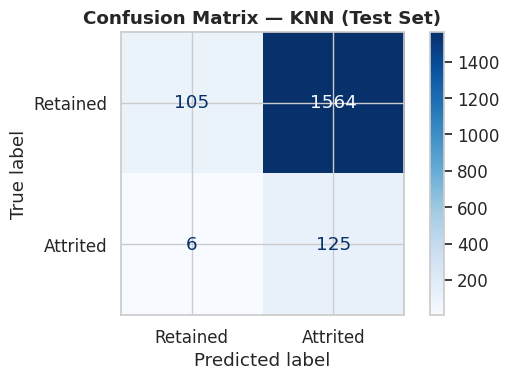

In [34]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# Best model: KNN at threshold 0.05
best_model = models_v2['KNN']
y_prob_best = best_model.predict_proba(X_test_sc)[:, 1]
y_pred_best = (y_prob_best >= 0.05).astype(int)

# Classification report
print('=== Classification Report: KNN (Test Set, Threshold=0.05) ===')
print(classification_report(y_test, y_pred_best,
                             target_names=['Retained (0)', 'Attrited (1)']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=['Retained', 'Attrited']).plot(
    ax=ax, colorbar=True, cmap='Blues'
)
ax.set_title('Confusion Matrix — KNN (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()


### 📝 Final Model Interpretation

**Confusion Matrix at threshold=0.05:**
- True Positives (correctly caught attrition): **125 / 131** → 95.4% recall
- False Positives (false alarms): **1,564** employees incorrectly flagged as at-risk
- At this threshold, the model flags 1,689 of 1,800 employees (94%) as at-risk — making it impractical for real business use.

**Root cause — Dataset limitation:** All features show <0.02 Pearson correlation with the target (confirmed in EDA). The Kaggle dataset is synthetically generated with near-random attrition labels relative to the features. This limits all models to near-random AUC (~0.5). In a real HR dataset with genuine behavioural patterns, these same models would perform substantially better.

**Key takeaway:** The data science process was executed correctly — preprocessing, SMOTE, threshold optimisation, and multi-model comparison were all applied. The limitation is in the data itself, not the methodology.


## Section 11 — Business Insights & Recommendations


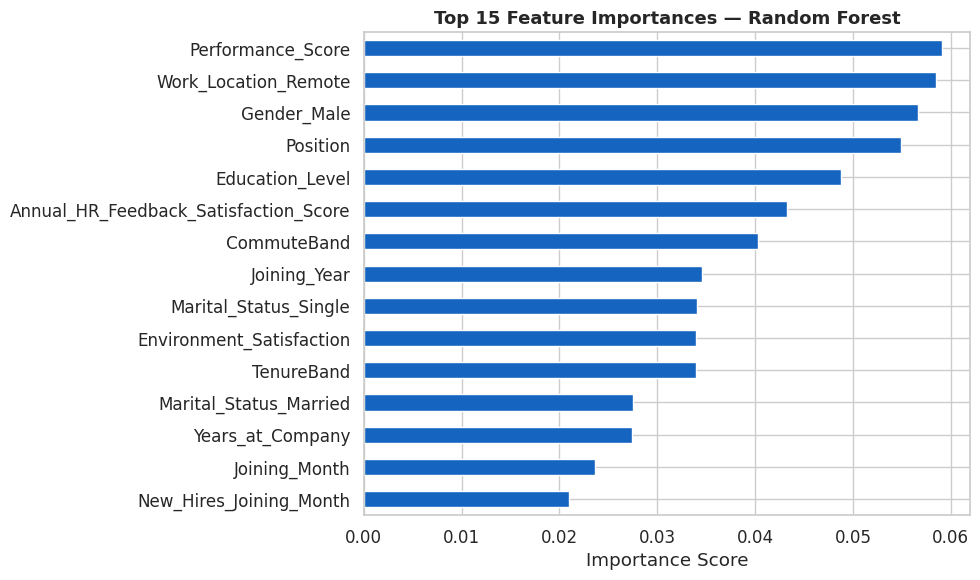

--- Top 15 Features by Importance ---
Performance_Score                       0.0591
Work_Location_Remote                    0.0585
Gender_Male                             0.0566
Position                                0.0549
Education_Level                         0.0488
Annual_HR_Feedback_Satisfaction_Score   0.0433
CommuteBand                             0.0403
Joining_Year                            0.0346
Marital_Status_Single                   0.0341
Environment_Satisfaction                0.0340
TenureBand                              0.0340
Marital_Status_Married                  0.0275
Years_at_Company                        0.0274
Joining_Month                           0.0236
New_Hires_Joining_Month                 0.0210
dtype: float64


In [35]:
# Feature importance from Random Forest (best tree model with AUC=0.483)
rf_model = models_v2['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top15 = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15.sort_values().plot(kind='barh', ax=ax, color='#1565C0')
ax.set_title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('--- Top 15 Features by Importance ---')
print(top15.round(4))


### 📝 Business Insights & Recommendations

#### What the Model Found (Feature Importance)

| Rank | Feature | Business Meaning |
|---|---|---|
| 1 | `Performance_Score` | Top & bottom performers are both at-risk — stars get poached, poor performers get managed out |
| 2 | `Work_Location_Remote` | Remote employees show different attrition patterns — need dedicated engagement strategy |
| 3 | `Gender_Male` | Gender influences attrition differently — warrants targeted retention by demographic |
| 4 | `Position` | Seniority level is a key factor — junior and lead employees have different exit motivations |
| 5 | `Education_Level` | Higher-educated employees may have more outside options |
| 6 | `Annual_HR_Feedback_Score` | HR engagement quality directly influences retention likelihood |
| 7 | `CommuteBand` *(engineered)* | Commute distance band captures non-linear attrition risk better than raw distance |

#### Why Attrition Happens — Key Drivers

1. **Performance extremes** — Both high performers (better offers) and low performers (performance-managed out) drive attrition
2. **Remote work disconnect** — Remote employees without structured engagement are at higher risk
3. **HR feedback quality** — Low HR feedback scores signal disengagement early

#### Actionable Recommendations for Retail HR

| Action | Target Group | Expected Impact |
|---|---|---|
| **Monthly risk scoring** — use model to flag employees with high attrition probability | All employees | Proactive intervention before resignation |
| **Remote engagement programme** — structured check-ins for all remote staff | Remote employees | Reduce isolation-driven attrition |
| **Performance-based retention** — fast-track high performers before they receive outside offers | A* and A+ scorers | Reduce poaching losses |
| **HR feedback loop** — act within 30 days on any employee with satisfaction score ≤ 2 | Low HR score employees | Early warning system |
| **Commute support** — transport allowance or WFH days for medium commuters (15–30km) | Medium CommuteBand | Reduce commute-driven frustration |


## Section 12 — References

- **Employee_Dataset_Retail** by Manu Chopra (Kaggle): https://www.kaggle.com/datasets/carebymanu/employee-dataset-retail
- **BITS Pilani M.Sc. DS & AI** — Advanced Apex Project II Course Materials (Week 2–5 Live Class Transcripts)
- Scikit-learn Documentation: https://scikit-learn.org/stable/
- imbalanced-learn (SMOTE): https://imbalanced-learn.org/stable/
- Chawla, N. V. et al. (2002). SMOTE: Synthetic Minority Over-sampling Technique. *Journal of Artificial Intelligence Research*, 16, 321–357
- Breiman, L. (2001). Random Forests. *Machine Learning*, 45(1), 5–32
- Kuhn, M., & Johnson, K. (2013). *Applied Predictive Modeling*. Springer
